In [4]:
import pandas as pd

# Dataset load pannu
df = pd.read_csv("retail_sales_dataset.csv")

df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Region,State,City,Category,Sub-Category,Product Name,Quantity,Discount,Sales,Profit
0,ORD-01578,2023-04-10,2023-04-11,Standard Class,CUST-0132,Consumer,West,Rajasthan,Udaipur,Technology,Machines,Label Maker,9,0.0,2989.98,615.54
1,ORD-00141,2025-06-16,2025-06-22,Second Class,CUST-0170,Home Office,West,Rajasthan,Jaipur,Office Supplies,Binders,View Binder,2,0.0,109.49,29.80
2,ORD-00111,2024-01-31,2024-02-02,Same Day,CUST-0386,Corporate,Central,Chhattisgarh,Raipur,Technology,Machines,Laminator,7,0.2,1393.01,18.71
3,ORD-00260,2024-04-10,2024-04-17,Same Day,CUST-0387,Corporate,North,Uttar Pradesh,Noida,Office Supplies,Art,Sketch Pad,3,0.0,15.04,2.87
4,ORD-01392,2024-05-18,2024-05-23,Same Day,CUST-0387,Home Office,Central,Madhya Pradesh,Bhopal,Technology,Phones,Smartphone X200,3,0.5,2059.15,-239.94


In [5]:
print(df.shape)
df.info()

(2015, 16)
<class 'pandas.DataFrame'>
RangeIndex: 2015 entries, 0 to 2014
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order ID      2015 non-null   str    
 1   Order Date    2015 non-null   str    
 2   Ship Date     2015 non-null   str    
 3   Ship Mode     2015 non-null   str    
 4   Customer ID   2015 non-null   str    
 5   Segment       2015 non-null   str    
 6   Region        2015 non-null   str    
 7   State         2015 non-null   str    
 8   City          2015 non-null   str    
 9   Category      2015 non-null   str    
 10  Sub-Category  2015 non-null   str    
 11  Product Name  2015 non-null   str    
 12  Quantity      2015 non-null   int64  
 13  Discount      1989 non-null   float64
 14  Sales         2015 non-null   float64
 15  Profit        2015 non-null   float64
dtypes: float64(3), int64(1), str(12)
memory usage: 252.0 KB


In [6]:
df.describe()

,Quantity,Discount,Sales,Profit
count,2015.000000,1989.000000,2015.000000,2015.000000
mean,5.480893,0.182831,2025.889811,114.784948
std,2.905924,0.173424,2174.767798,327.404425
min,1.000000,0.000000,7.770000,-1110.490000
25%,3.000000,0.000000,410.680000,1.670000
50%,6.000000,0.150000,1088.930000,47.630000
75%,8.000000,0.300000,3087.015000,168.505000
max,10.000000,0.500000,11055.020000,2265.610000


In [7]:
df.isnull().sum()

Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Segment          0
Region           0
State            0
City             0
Category         0
Sub-Category     0
Product Name     0
Quantity         0
Discount        26
Sales            0
Profit           0
dtype: int64

In [8]:
# Missing values evlo irukku pathunga
print(df.isnull().sum())

Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Segment          0
Region           0
State            0
City             0
Category         0
Sub-Category     0
Product Name     0
Quantity         0
Discount        26
Sales            0
Profit           0
dtype: int64


In [9]:
# Discount missing na, 0 nu fill pannu (discount illa-nu assume)
df['Discount'] = df['Discount'].fillna(0)

# Check pannu - ippo missing values illama irukanum
print(df.isnull().sum())

Order ID        0
Order Date      0
Ship Date       0
Ship Mode       0
Customer ID     0
Segment         0
Region          0
State           0
City            0
Category        0
Sub-Category    0
Product Name    0
Quantity        0
Discount        0
Sales           0
Profit          0
dtype: int64


In [10]:
# Evlo duplicate rows irukku check pannu
print("Duplicates:", df.duplicated().sum())

# Duplicates remove pannu
df = df.drop_duplicates()

# Check pannu
print("After removing:", df.duplicated().sum())
print(df.shape)

Duplicates: 15
After removing: 0
(2000, 16)


In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df.info()

<class 'pandas.DataFrame'>
Index: 2000 entries, 0 to 2014
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      2000 non-null   str           
 1   Order Date    2000 non-null   datetime64[us]
 2   Ship Date     2000 non-null   datetime64[us]
 3   Ship Mode     2000 non-null   str           
 4   Customer ID   2000 non-null   str           
 5   Segment       2000 non-null   str           
 6   Region        2000 non-null   str           
 7   State         2000 non-null   str           
 8   City          2000 non-null   str           
 9   Category      2000 non-null   str           
 10  Sub-Category  2000 non-null   str           
 11  Product Name  2000 non-null   str           
 12  Quantity      2000 non-null   int64         
 13  Discount      2000 non-null   float64       
 14  Sales         2000 non-null   float64       
 15  Profit        2000 non-null   float64       
dtypes: d

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chart style set pannu
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

C:\Users\acer\AppData\Local\Temp\ipykernel_1456\3282948745.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette="Blues_d")


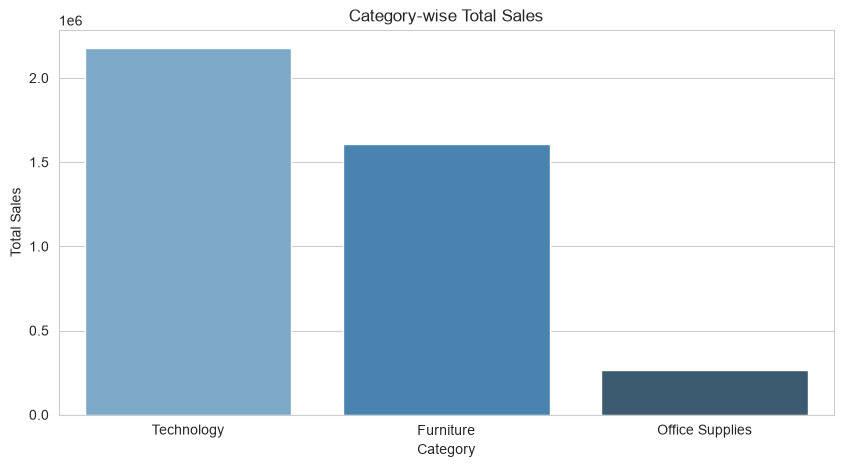

In [13]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure()
sns.barplot(x=category_sales.index, y=category_sales.values, palette="Blues_d")
plt.title("Category-wise Total Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

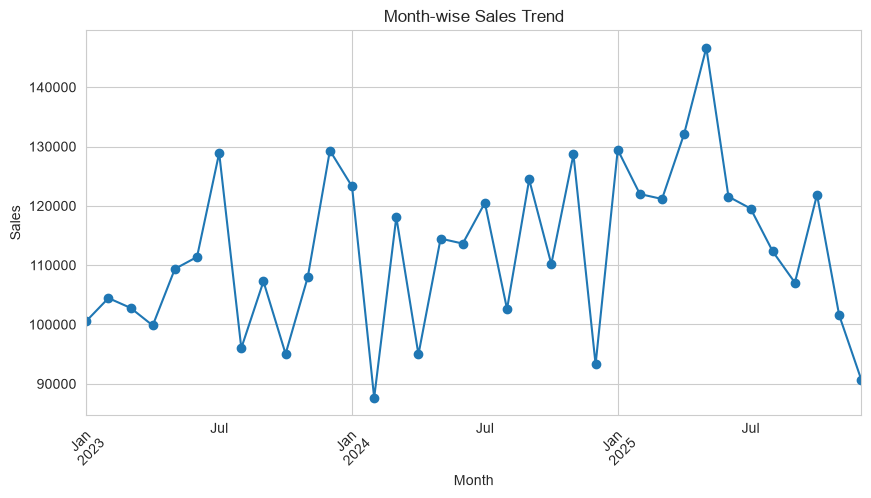

In [14]:
df['Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure()
monthly_sales.plot(kind='line', marker='o')
plt.title("Month-wise Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_1456\1791240534.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_profit.index, y=region_profit.values, palette="Greens_d")


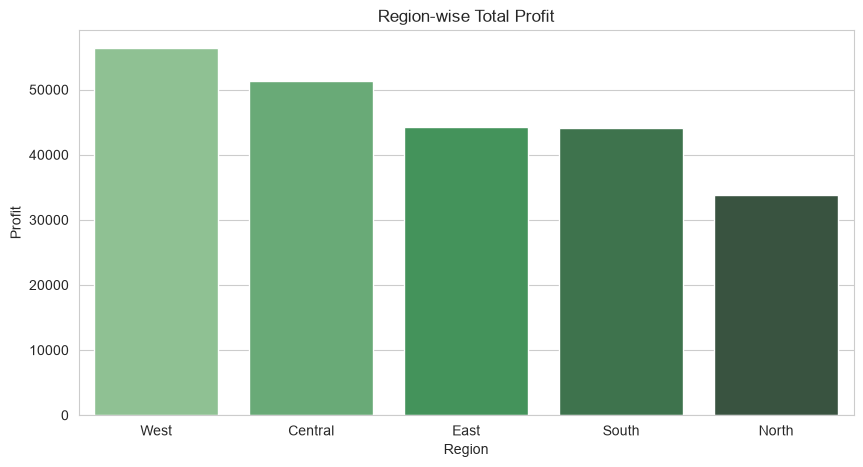

In [15]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

plt.figure()
sns.barplot(x=region_profit.index, y=region_profit.values, palette="Greens_d")
plt.title("Region-wise Total Profit")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_1456\338952927.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="Oranges_d")


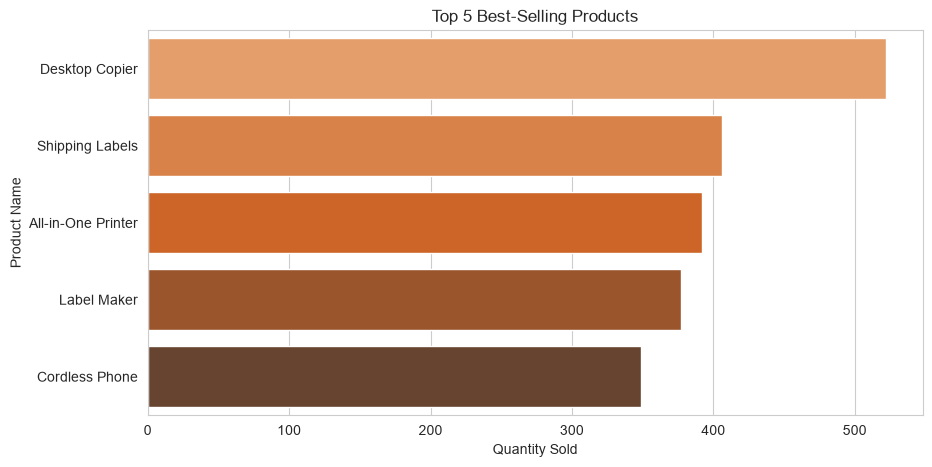

In [16]:
top_products = df.groupby('Product Name')['Quantity'].sum().sort_values(ascending=False).head(5)

plt.figure()
sns.barplot(x=top_products.values, y=top_products.index, palette="Oranges_d")
plt.title("Top 5 Best-Selling Products")
plt.xlabel("Quantity Sold")
plt.show()

## Key Insights

1. **Best Category:** Based on Chart 1, identify which category generates the highest sales
2. **Sales Trend:** Based on Chart 2, identify which month/season had the highest and lowest sales
3. **Best Region:** Based on Chart 3, identify which region generates the most profit, and which region is running at a loss
4. **Top Products:** Based on Chart 4, identify which products are selling the most

## Recommendations
- (Write 2-3 lines on what the business should do based on your insights)
- Example: "The Technology category has low profit margins; the discount strategy should be revised"

## Key Insights

1. **Best Category:** Technology generates the highest total sales (~₹21.8 lakh), 
   followed by Furniture (~₹16 lakh). Office Supplies contributes the least (~₹2.7 lakh).

2. **Sales Trend:** Sales peaked in May 2025 (~₹1.47 lakh) and were lowest in 
   February 2024 (~₹87,648), showing seasonal fluctuation across months.

3. **Best Region:** The West region generates the highest profit (~₹56,318), 
   followed by Central (~₹51,379). The North region has the lowest profit (~₹33,840), 
   indicating room for improvement there.

4. **Top Products:** Desktop Copier, Shipping Labels, and All-in-One Printer are the 
   top-selling products by quantity, showing strong demand for office equipment and supplies.

## Recommendations
- Since Technology drives the most sales, the business should continue investing in this 
  category while monitoring its profit margins closely.
- The North region has comparatively low profit; a review of pricing, discounts, or marketing 
  strategy in that region could help improve performance.
- Since sales peak around May, the business could plan inventory and promotions in advance 
  for that period.

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Simple model: Quantity, Discount vachi Sales predict pannurom
X = df[['Quantity', 'Discount']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print("Mean Absolute Error:", mean_absolute_error(y_test, predictions))

Mean Absolute Error: 1395.7849711831775


## Prediction Model
Simple Linear Regression model use panni, Quantity mattrum Discount vachi 
Sales predict panna try pannen. Mean Absolute Error: ~1395. 
Idha innum improve panna, Category, Region mathiri features add pannalam.

## Conclusion

This project analyzed a retail sales dataset covering orders across multiple regions, 
categories, and time periods. After cleaning the data (handling missing values and 
duplicates) and performing exploratory data analysis, several clear patterns emerged.

Technology and Furniture are the two strongest categories in terms of sales, while 
Office Supplies, despite lower sales, may still offer steady demand. Profitability 
varies significantly by region — the West region performs best, while the North 
region lags behind and may need attention in pricing or marketing strategy. Sales 
also show seasonal variation, with certain months consistently outperforming others.

A simple Linear Regression model was also built to predict Sales based on Quantity 
and Discount. While the model provides a basic prediction capability, its accuracy 
could be improved by including additional features such as Category, Region, and 
Segment in future iterations.

Overall, this project demonstrates how real-world retail data can be cleaned, 
analyzed, and visualized to generate actionable business insights — fulfilling the 
core objective of applying data science skills in a real-world context.